# Natural Language Processing - Final project

___ 



Date: 20/01/2026

**INTRODUCTION**

In this final project of Natural Language Processing we will be carrying a variety of tasks related to the most important topics we have covered during the course.

We will build an ad hoc corpus from the *News Category Dataset*, publicly available at [Kaggle](https://www.kaggle.com/datasets/rmisra/news-category-dataset). It contains 210k news headlines from 2012 to 2018 from [HuffPost](https://www.huffpost.com/), aswell as a brief description, the author, the date and a label on the category of the piece of news. 

## Imports

In [1]:
import os

# ضع هنا مسار مجلد المشروع على جهازك المحلي
path_to_folder = r"C:\Users\lenovo\Downloads\GitHup_Projects\NLP_NewsCategory-main"
os.chdir(path_to_folder)

print("Current working directory:", os.getcwd())


Current working directory: C:\Users\lenovo\Downloads\GitHup_Projects\NLP_NewsCategory-main


In [2]:
#General libraries
import numpy as np
import pandas as pd
import zipfile as zp
from termcolor import colored
import seaborn as sn
import time
import matplotlib.pyplot as plt

# هذا للسماح بعرض الرسوميات داخل Jupyter
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


C:\Users\lenovo\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# =======================================
# 1️⃣ تثبيت المكتبات (مرة واحدة عبر Terminal)
# =======================================
# لا تستخدم !pip داخل الكود على Windows
# نفذ هذه الأوامر في موجه الأوامر أو PowerShell مرة واحدة:
# pip install --upgrade gensim==3.8.3
# pip install pyLDAvis==2.1.2

import gensim
print(gensim.__version__)

import pyLDAvis
import pyLDAvis.gensim
print(pyLDAvis.__version__)


3.8.3
2.1.2


In [4]:
# =======================================
# 2️⃣ استيراد المكتبات
# =======================================
from gensim.models.phrases import Phrases
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.wrappers import LdaMallet
from gensim.models.wrappers.ldamallet import malletmodel2ldamodel
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.models import FastText

import pyLDAvis.gensim as gensimvis
import pyLDAvis

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [5]:
# =======================================
# 3️⃣ كلاس لقراءة الملفات النصية
# =======================================
class IterableSentence_fromfile(object):
    def __init__(self, filename):
        self.__filename = filename
    
    def __iter__(self):
        # أضفنا encoding='utf-8' لتجنب مشاكل قراءة النصوص
        for line in open(self.__filename, encoding='utf-8'):
            yield line.split()


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [6]:

# =======================================
# 4️⃣ ضبط Java/Mallet على Windows
# =======================================
import os

# ضع مسار تثبيت JDK 8 هنا (يمكن تثبيت Java 8 جنبًا إلى جنب مع Java 17)
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-1.8"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

# تحقق من إصدار Java الذي يستخدمه Notebook
!java -version



C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
java version "1.8.0_381"
Java(TM) SE Runtime Environment (build 1.8.0_381-b09)
Java HotSpot(TM) 64-Bit Server VM (build 25.381-b09, mixed mode)


In [7]:
# =======================================
# 5️⃣ ضبط مسار Mallet
# =======================================
# حمّل Mallet وضعه في مجلد ثابت مثل C:\mallet
mallet_path = r"C:\mallet\bin\mallet"  # عدّل حسب مجلد Mallet على جهازك

# مثال لاستخدامه لاحقًا مع LdaMallet:
# lda_model = LdaMallet(mallet_path, corpus=corpus, num_topics=10, id2word=dictionary)


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [8]:
#Scikit

#Preprocessing: normalization, split, categorical label encoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import Counter #To count how many samples of each class
from sklearn.preprocessing import LabelEncoder

#Cross validation
from sklearn.model_selection import GridSearchCV

#Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#Metrics 
from sklearn import metrics



C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [14]:
# Supress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning) 

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## **0. DATA ACQUISITION AND PREPROCESSING PIPELINE**
 

In [15]:
#Load the original News Category dataset
df = pd.read_json('./Dataset/News_Category_Dataset_v3.json', lines=True)

print("Shape:", df.shape)
df.head()

Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [16]:
# دمج العنوان والوصف القصير لإنشاء عمود news_corpus بديل
df['news_corpus'] = df['headline'] + '. ' + df['short_description']
df_short = df.copy()  # مثل الكود الأصلي الذي يختار subset
df_short = df_short[['headline', 'news_corpus', 'category']].dropna()

print(df_short.head())


                                            headline  \
0  Over 4 Million Americans Roll Up Sleeves For O...   
1  American Airlines Flyer Charged, Banned For Li...   
2  23 Of The Funniest Tweets About Cats And Dogs ...   
3  The Funniest Tweets From Parents This Week (Se...   
4  Woman Who Called Cops On Black Bird-Watcher Lo...   

                                         news_corpus   category  
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS  
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS  
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY  
3  The Funniest Tweets From Parents This Week (Se...  PARENTING  
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS  


In [18]:
# قد تم تنفيذه و الملف جاهز للعلم عليه 
# تنفيذ الكود مرة واحده 
# تم التنفيذ

# import spacy
# import pandas as pd
# from tqdm import tqdm

# # --------------------------------------------
# # تحميل نموذج Spacy المتوسط
# # --------------------------------------------
# !python -m spacy download en_core_web_md

# nlp = spacy.load('en_core_web_md')

# # تعطيل أجزاء من النموذج غير الضرورية للتسريع
# nlp.disable_pipe('parser')
# nlp.disable_pipe('ner')

# # --------------------------------------------
# # إعدادات preprocessing
# # --------------------------------------------
# valid_POS = set(['VERB', 'NOUN', 'ADJ', 'PROPN'])

# specific_stw = set([
#     'agreeing', 'email', 'people', 'year','man', 'new','woman',
#     'clicking', 'say','sign','message', 'advertising', 'let', 'send', 
#     'reporter', 'click', 'enter', 'sign', 'customized', 'messages', 'twitter', 
#     'editor', 'huffpost', 'agree', 'customize', 'marketing', 'partner'
# ])

# # --------------------------------------------
# # دالة preprocessing
# # --------------------------------------------
# def text_preprocessing(doc):
#     return [
#         token.lemma_.lower()
#         for token in doc
#         if token.is_alpha and token.pos_ in valid_POS
#         and not token.is_stop and token.lemma_.lower() not in specific_stw
#     ]

# # --------------------------------------------
# # دمج العنوان + نص الخبر
# # --------------------------------------------
# df_short['news'] = (df_short['headline'] + '. ' + df_short['news_corpus']).astype(str)

# # تحويل العمود إلى قائمة نصوص
# texts = df_short['news'].tolist()

# # --------------------------------------------
# # معالجة النصوص باستخدام nlp.pipe + tqdm
# # --------------------------------------------
# tqdm.pandas()  # لعرض شريط التقدم
# cleaned_texts = [
#     text_preprocessing(doc) for doc in nlp.pipe(texts, batch_size=50, disable=['parser','ner'])
# ]

# # إنشاء العمود الجديد في DataFrame
# df_short['news_clean'] = cleaned_texts

# # --------------------------------------------
# # حفظ الملف النهائي بصيغة متوافقة
# # --------------------------------------------
# path = './Dataset/Final_NewsCorpus_Clean.json'
# df_short.to_json(path, orient='records', lines=True)
# print(f"Saved cleaned data to {path}")


## **1. DATA LOADING**

Load the data we preprocessed in section 0. as a Pandas dataframe.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models.phrases import Phrases

# قراءة الـ JSON النهائي الذي أنشأناه
corpus_df = pd.read_json('./Dataset/Final_NewsCorpus_Clean.json', lines=True)

# إنشاء قائمة الـ corpus
mycorpus = [doc for doc in corpus_df['news_clean']]

print("The corpus contains %i documents." % len(corpus_df))


The corpus contains 209527 documents.


\* *NOTE: one entry was removed because it yielded an error in the word embedding vectorization*.

### 1.1 Preprocessing

The only preprocessing we do to the final corpus is bi-gram detection, as many terms in the *News Dataset* are diadic and appear very often. For example: 'White House', 'United States', 'Health Care', etc (see section 1.2).

We also tried to detect tri-grams such as 'New York City' or 'President Donald Trump', but we discarded it after not being able to select a proper threshold to avoid false positives.

In [20]:
# 1) N-gram detection

#Bigrams
phrase_model = Phrases(mycorpus, min_count=2, threshold=10)
mycorpus = [el for el in phrase_model[mycorpus]]

### 1.2 Data analysis


1) **Distribution of documents per labeled *CATEGORY*.**

The original dataset presented 42 categories. Our subpartition only contains 35.

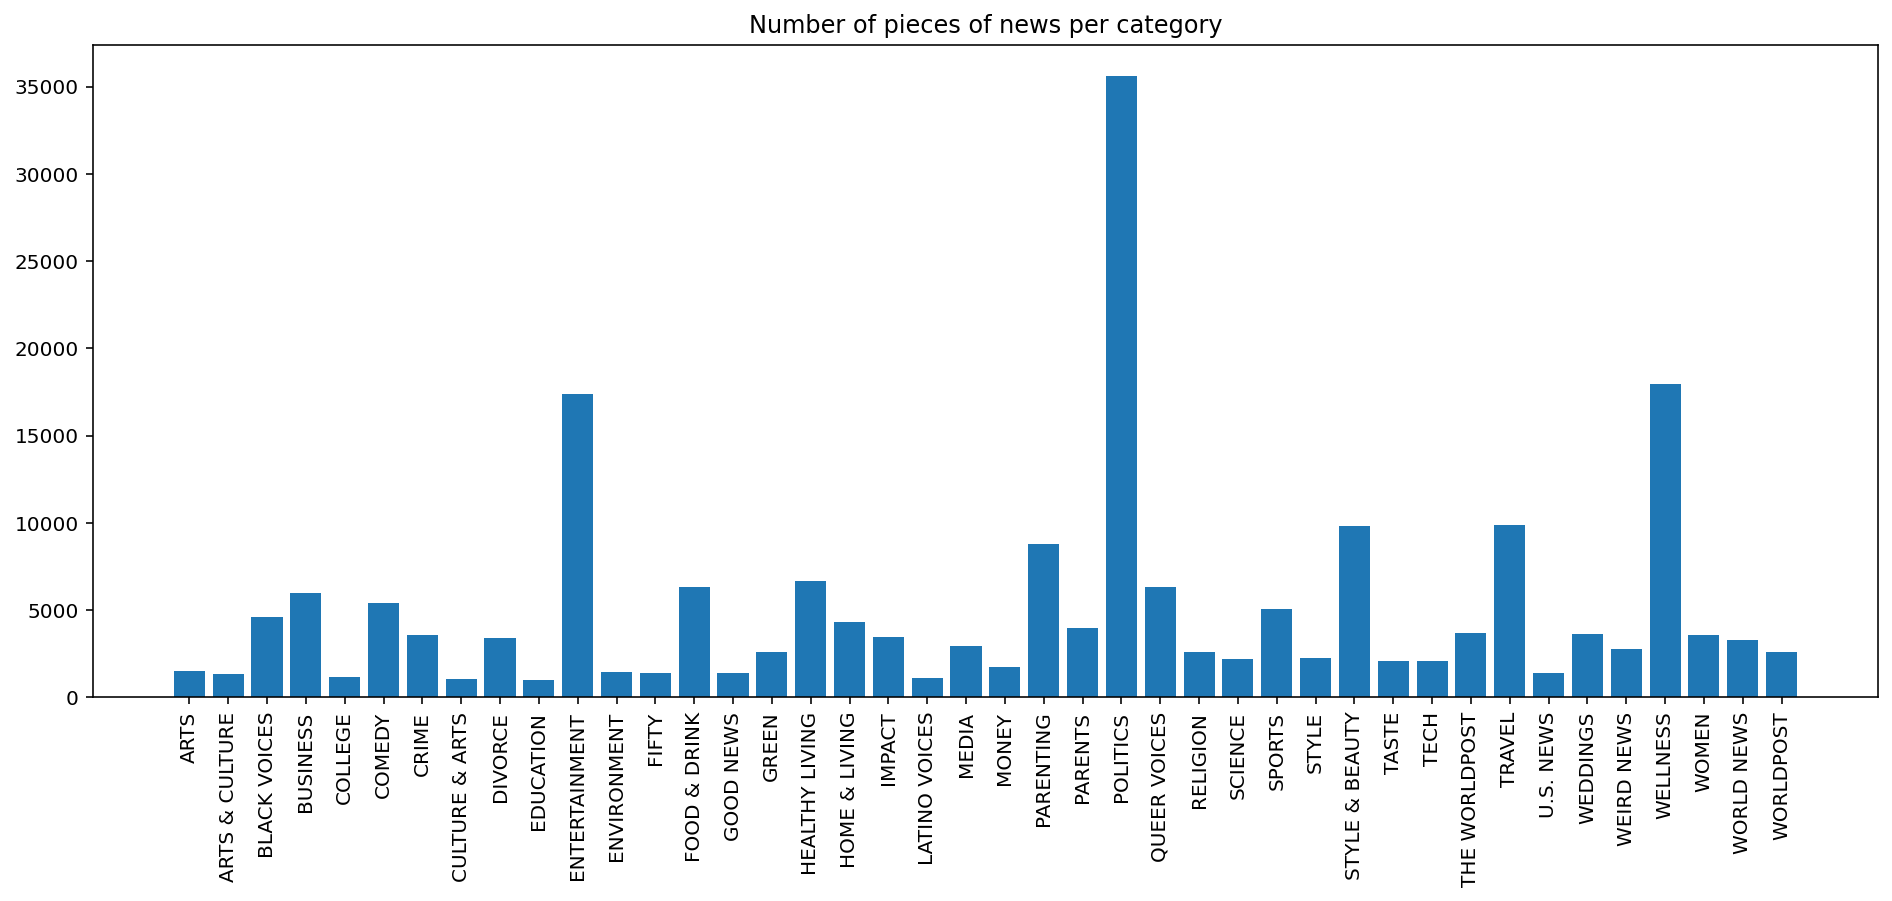

In [21]:
categories = np.unique(corpus_df['category'])
num_news = []

for cat in categories:
  num_news.append(len(np.where(corpus_df['category'] == cat)[0]))

plt.figure(figsize=(16,6))
plt.title("Number of pieces of news per category")
plt.bar(categories, num_news)
#plt.yscale('log')
plt.xticks(ticks=range(len(categories)), labels=categories, rotation=90)
plt.show()



2) **N-grams**

In [22]:
tokens_Ngrams = []

for doc in mycorpus:
  for token in doc:
    if '_' in token:
      tokens_Ngrams.append(token)

Ngrams, counts = np.unique(np.array(tokens_Ngrams), return_counts=True)

import pandas as pd

data = {'Ngram': Ngrams, 'Counts': counts}

Ngrams_df = pd.DataFrame(data)
Ngrams_df.sort_values(by=['Counts'], ascending=False, inplace=True)

# Top 10 most common N_grams
Ngrams_df.head(20)


,Ngram,Counts
17268,donald_trump,10904
27524,hillary_clinton,3293
64971,white_house,2752
26858,health_care,1885
58045,supreme_court,1863
11004,climate_change,1665
5265,bernie_sanders,1623
40578,need_know,1059
57927,super_bowl,1058
62452,united_states,1029


**3) Average number of words per doc**

Average number of words per article:  17.35657457034177


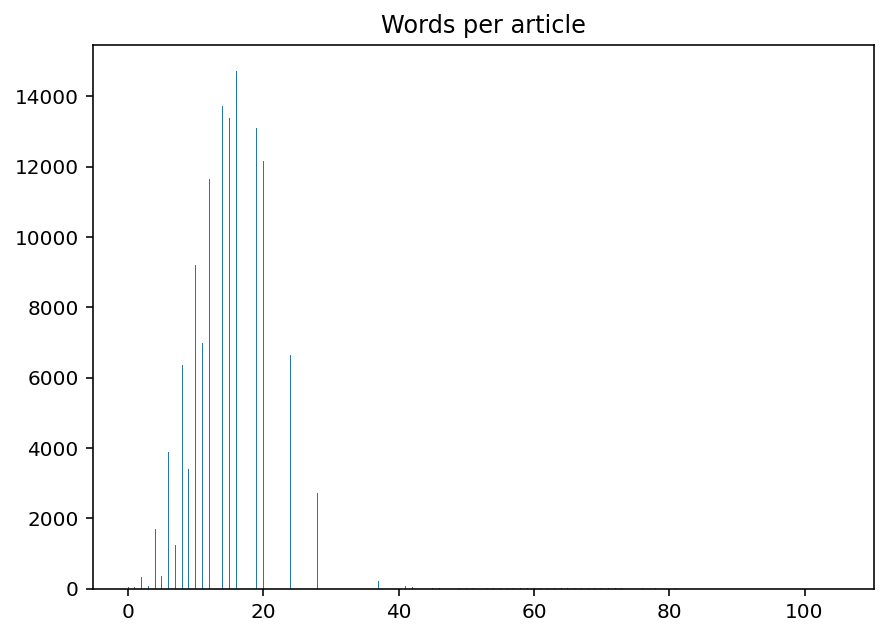

In [23]:
n_words = []

for doc in mycorpus:
  n_words.append(len(doc))

print("Average number of words per article: ", np.mean(np.array(n_words)))

#Filter out extreme to better visualize the histogram
n_words = [n for n in n_words if n < 2000]  
plt.figure(figsize=(7,5))
plt.title("Words per article")
plt.hist(n_words, bins=1024)
plt.show()



## **2. VECTOR REPRESENTATIONS**

In this section we perform the vectorization of the document via: Bag-of-words, TFIDF, document embedding, LDA topic modeling and Neural topic modeling.

### 2.1 Dictionary and BoW

After creating the dictionary, we filter out very uncommon terms (that appear in less than 10 articles) and very common ones (on more than 80% of the articles). This is useful not only to reduce the dimensionality of the TFIDF matrix, but also for a better result in the topic modeling task.

In [24]:
no_below = 10 #Minimum number of documents to keep a term in the dictionary
no_above = .80 #Maximum proportion of documents in which a term can appear to be kept in the dictionary

D = Dictionary(mycorpus)
D.filter_extremes(no_below=no_below,no_above=no_above)

mycorpus_bow = [D.doc2bow(doc) for doc in mycorpus]

print("Dictionary contains %i words" %len(D))

Dictionary contains 22968 words


### 2.2 TFIDF

The TF-IDF matrix is directly calculated from the BoW representation.

In [25]:
tfidf = TfidfModel(mycorpus_bow)

mycorpus_tfidf = tfidf[mycorpus_bow]

### 2.3 Word Embeddings

Here we train a Fast Text model with embedding size = 200. The keyed vectors are then saved for better re-use.

In [26]:
import os
import gc
import numpy as np
from gensim.models import FastText

# --------------------------------------------
# إعداد المجلد لحفظ النموذج
# --------------------------------------------
os.makedirs("./W2V", exist_ok=True)
save_path = "./W2V/fasttext_100.kv"

# --------------------------------------------
# التحقق إذا كان النموذج محفوظ مسبقًا
# --------------------------------------------
if os.path.exists(save_path):
    from gensim.models import KeyedVectors
    wv = KeyedVectors.load(save_path, mmap='r')
    print(f"✅ Loaded existing FastText word vectors from: {save_path}")
else:
    # --------------------------------------------
    # تصغير الكوربوس إذا كان ضخم
    # --------------------------------------------
    # افتراض: mycorpus = قائمة جمل (كل جملة قائمة كلمات)
    min_count = 5   # تجاهل الكلمات النادرة
    vector_size = 100  # تقليل حجم المتجه
    iterations = 5  # عدد التكرارات
    workers = 4    # عدد الـ threads

    # --------------------------------------------
    # تدريب نموذج FastText
    # --------------------------------------------
    print("⏳ Training FastText model...")
    model_fasttext = FastText(
        sentences=mycorpus,
        size=vector_size,   # استخدم size بدل vector_size في gensim القديمة
        window=5,
        min_count=min_count,
        workers=workers,
        sg=1,               # skip-gram
        iter=iterations,
        seed=42
    )

    # --------------------------------------------
    # تحويل المتجهات إلى float32 لتقليل استهلاك الذاكرة
    # --------------------------------------------
    model_fasttext.wv.vectors = model_fasttext.wv.vectors.astype(np.float32)
    model_fasttext.wv.vectors_ngrams = model_fasttext.wv.vectors_ngrams.astype(np.float32)

    # --------------------------------------------
    # حفظ Word Vectors بصيغة .kv
    # --------------------------------------------
    model_fasttext.wv.save(save_path)
    print(f"✅ FastText word vectors saved successfully at: {save_path}")

    # --------------------------------------------
    # تنظيف الذاكرة
    # --------------------------------------------
    del model_fasttext
    gc.collect()


✅ Loaded existing FastText word vectors from: ./W2V/fasttext_100.kv


In [27]:
# 2) Load keyed vectors

from gensim.models import KeyedVectors

wv = KeyedVectors.load("./W2V/fasttext_100.kv", mmap='r')
print("✅ Word vectors loaded successfully")


✅ Word vectors loaded successfully


In [28]:
# 3) Get single embedding as mean of word embeddings in the News text

def get_mean_vector(model, doc_tfidf, D):
  """
  Calculates a document embedding representation by weighting the embeddings of the words with their tf-idf factor.

  Args:
    model: (word vectors) word2vec model with the embeddings of all the words.
    doc_tfidf: (list) list containing the tf-idf weights of the document. 
    D: (dictionary) dictionary obtained from the corpora.

  Returns:
    vec: (np.array) document embedding.  

  """
 
  embeddings = []
  eps = 1e-9
  for i in doc_tfidf:
    # 1) Word embedding
    word = D[i[0]]
    word_emb = model[word]

    # 2) TDIDF weight
    weight = i[1]

    # 3) Weighted embedding
    embeddings.append(word_emb * weight + eps)

  #print(len(embeddings))
  vec = np.mean(np.asarray(embeddings), axis=0)

  return vec

In [29]:
# 4) Create matrix of size [N_docs, embedding_size] with the mean embedding of each doc

embedding_size = wv.vector_size
N_news = len(mycorpus)

X_w2v = np.zeros((N_news, embedding_size))

for i in range(len(mycorpus_tfidf)):  
  vec = get_mean_vector(wv, mycorpus_tfidf[i], D)

  X_w2v[i] = vec

C:\Users\lenovo\AppData\Roaming\Python\Python38\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\lenovo\AppData\Roaming\Python\Python38\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### 2.4 LDA Topic modeling


In this section we carry out a Latent Dirichlet Allocation topic modeling. To select the number of topics, we first perform a search over a set of values, ```[15, 20, 30, 35, 40, 45, 50, 60, 70]```, a keep the one that yields the highest coherence. 

*NOTE: this search was executed several times (to iteratively improve the preprocessing pipeline) and the optimal value differed between 40, 45 and 50. By inspecting the contents of the topics in each case, we didn't notice a significant change.*

In [30]:
!wget http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
!unzip mallet-2.0.8.zip

os.environ['MALLET_HOME'] = 'mallet-2.0.8'
mallet_path = 'mallet-2.0.8/bin/mallet' # you should NOT need to change this 

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.



=== Processing 15 topics ===
Loaded existing model for 15 topics
Coherence already saved: 0.2470

=== Processing 20 topics ===
Loaded existing model for 20 topics
Coherence already saved: 0.2433

=== Processing 30 topics ===
Loaded existing model for 30 topics
Coherence already saved: 0.2378

=== Processing 35 topics ===
Loaded existing model for 35 topics
Coherence already saved: 0.2390

=== Processing 40 topics ===
Loaded existing model for 40 topics
Coherence already saved: 0.2461

=== Processing 45 topics ===
Loaded existing model for 45 topics
Coherence already saved: 0.2660

=== Processing 50 topics ===
Loaded existing model for 50 topics
Coherence already saved: 0.2658

=== Processing 60 topics ===
Loaded existing model for 60 topics
Coherence already saved: 0.2959

=== Processing 70 topics ===
Loaded existing model for 70 topics
Coherence already saved: 0.3337


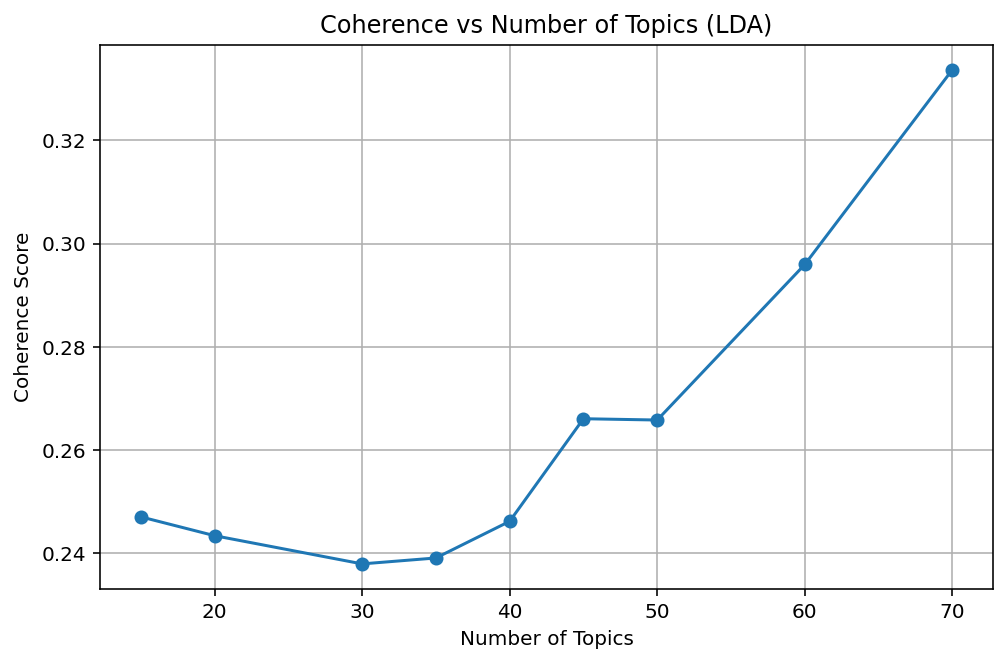

In [31]:
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import pickle
import os

# ======== إعداد قائمة المواضيع وعددها =========
n_topics = [15, 20, 30, 35, 40, 45, 50, 60, 70]

# ======== محاولة استرجاع النتائج المحفوظة =========
if os.path.exists("coherence_scores.pkl"):
    with open("coherence_scores.pkl", "rb") as f:
        coherence_dict = pickle.load(f)
else:
    coherence_dict = {}  # {num_topics: coherence_score}

# ======== تدريب النماذج أو تحميلها إذا كانت محفوظة =========
for n in n_topics:
    print(f"\n=== Processing {n} topics ===")
    
    model_filename = f"lda_model_{n}_topics.model"
    
    # إذا النموذج موجود، حمّله
    if os.path.exists(model_filename):
        lda = LdaModel.load(model_filename)
        print(f"Loaded existing model for {n} topics")
    else:
        # تدريب النموذج
        lda = LdaModel(
            corpus=mycorpus_bow,
            id2word=D,
            num_topics=n,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        # حفظ النموذج بعد التدريب
        lda.save(model_filename)
        print(f"Saved model for {n} topics")
    
    # حساب coherence إذا لم يتم حفظه مسبقًا
    if n not in coherence_dict:
        coherencemodel = CoherenceModel(
            model=lda,
            texts=mycorpus,
            dictionary=D,
            coherence='c_v'
        )
        c = coherencemodel.get_coherence()
        coherence_dict[n] = c
        print(f"Coherence = {c:.4f}")
        
        # حفظ النتائج بعد كل نموذج
        with open("coherence_scores.pkl", "wb") as f:
            pickle.dump(coherence_dict, f)
    else:
        print(f"Coherence already saved: {coherence_dict[n]:.4f}")

# ======== رسم النتائج =========
plt.figure(figsize=(8,5))
topics = list(coherence_dict.keys())
scores = list(coherence_dict.values())
plt.plot(topics, scores, marker='o')
plt.title("Coherence vs Number of Topics (LDA)")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.grid(True)
plt.show()


In [32]:

# # 2) Re-train model with highest coherence for more iterations

import os
import numpy as np
from gensim.models import LdaModel

# =============================
# مسار حفظ نموذج LDA
# =============================
LDA_MODEL_PATH = "lda_final_model"

# =============================
# اختيار أفضل عدد مواضيع
# =============================
best_n_topic = max(coherence_dict, key=coherence_dict.get)
print("Final number of topics:", best_n_topic)

# =============================
# تحميل النموذج أو تدريبه
# =============================
if os.path.exists(LDA_MODEL_PATH):
    print("📦 Loading saved LDA model...")
    lda_final = LdaModel.load(LDA_MODEL_PATH)
else:
    print("🚀 Training final LDA model...")

    lda_final = LdaModel(
        corpus=mycorpus_bow,
        id2word=D,
        num_topics=best_n_topic,
        random_state=42,
        passes=20,              # عدد مرور أعلى لتحسين الجودة
        alpha='auto',
        per_word_topics=True
    )

    lda_final.save(LDA_MODEL_PATH)
    print("💾 LDA model saved successfully!")

# =============================
# توزيع المواضيع لكل مستند
# =============================
topics_in_doc = lda_final.get_document_topics(mycorpus_bow)

print("✅ Topics distribution extracted successfully")


Final number of topics: 70
📦 Loading saved LDA model...
✅ Topics distribution extracted successfully


Now we visualize the obtained topics and check if they relate to any of the categories we have in the labels or to any of the events that have been covered in the news during the past few years. 


In [33]:
# ============================================
# 3) Visualize topic representation with LDAvis
# (CACHED – runs once only)
# ============================================

import pyLDAvis
import pyLDAvis.gensim
import os

output_file = "lda_topics.html"

# --------------------------------------------
# إذا كان الملف موجود لا تعيد الحساب
# --------------------------------------------
if os.path.exists(output_file):
    print("📂 LDAvis file already exists")
    print("🌐 افتحه مباشرة في المتصفح:")
    print(output_file)

else:
    print("⏳ Generating LDAvis (this will run once only)...")

    vis_data = pyLDAvis.gensim.prepare(
        lda_final,
        mycorpus_bow,
        D,
        sort_topics=False,
        R=10,           # تقليل الكلمات لتخفيف الحمل
        n_jobs=1,       # تعطيل multiprocessing (مهم)
        mds='pcoa'      # أسرع وأخف من tsne
    )

    pyLDAvis.save_html(vis_data, output_file)

    print("✅ تم إنشاء ملف LDAvis بنجاح")
    print(f"📁 اسم الملف: {output_file}")



📂 LDAvis file already exists
🌐 افتحه مباشرة في المتصفح:
lda_topics.html


Some of the most easily identifiable topics are:

*   [28] Covid19 pandemic.
*   [38] Russia-Ukraine war.
*   [12] and [23] American presidential elections.
*   [4] Donald Trump.
*   [10] Movies, cinema, Hollywood. 
*   [35] Gun shootings.
*   [22] Racism.
*   [11] Sexual abuse/allegations.
*   [36] Education, schools, University. 
*   [39] Religion.
*   [26] Climate change.




## **3. CLASSIFICATION TASK**



### 3.1 Preprocessing

As we saw in 1.2, the dataset is highly unbalanced in terms of documents per category. In order to simplify the problem, we select *POLITICS*, *WELLNESS* and *ENTERTAINMENT* as stand alone classes and merge everything else into an *OTHER* class. 

In [34]:
#Categorical labels
Y_cat = corpus_df['category'].values

Y = np.zeros((len(Y_cat)), dtype=int)

#Simplify the problem to 4 classes: 'OTHER': 0, 'POLITICS': 1, 'WELLNESS': 2, 'ENTERTAINMENT': 3
Y[np.where(Y_cat == 'POLITICS')] = 1
Y[np.where(Y_cat == 'WELLNESS')] = 2
Y[np.where(Y_cat == 'ENTERTAINMENT')] = 3


Yclasses = ["OTHER", "POLITICS", "WELLNESS", "ENTERTAINMENT"]

print(Counter(Y))





Counter({0: 138618, 1: 35602, 2: 17945, 3: 17362})


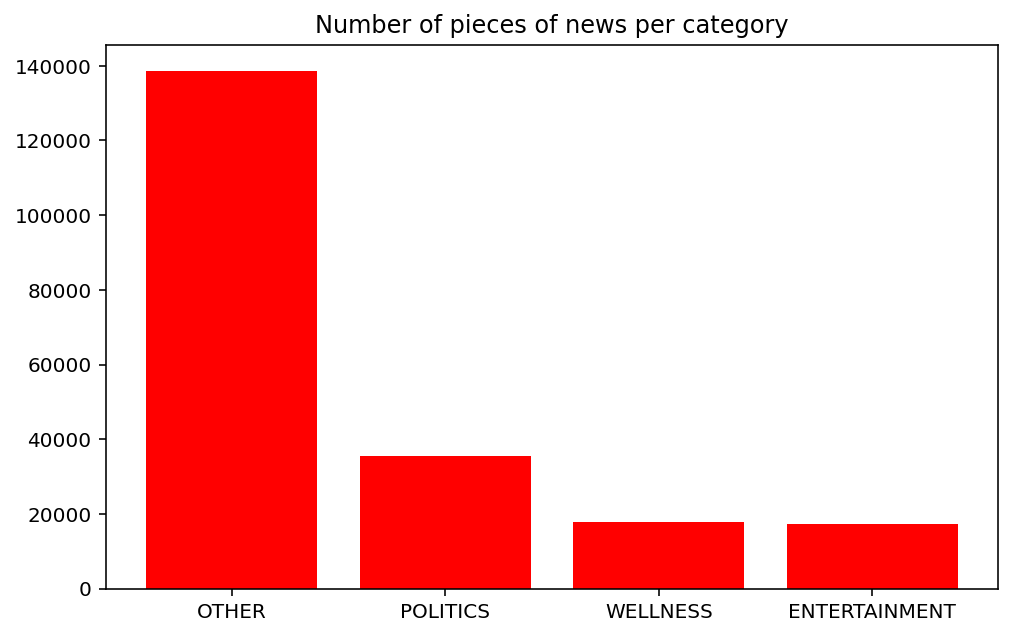

In [35]:
categories = np.unique(Y)
num_news = []

for cat in categories:
  num_news.append(len(np.where(Y == cat)[0]))

plt.figure(figsize=(8,5))
plt.title("Number of pieces of news per category")
plt.bar(categories, num_news, color='r')
#plt.yscale('log')
plt.xticks(ticks=range(len(categories)), labels=Yclasses, rotation=0)
plt.show()

### 3.2 TFIDF

In [37]:
from gensim.matutils import corpus2csc

# عدد المصطلحات
num_terms = len(D.keys())

# تحويل الـ TFIDF مباشرة إلى sparse matrix بصيغة Compressed Sparse Column
# ثم تحويلها إلى CSR (أسهل للتعلم الآلي)
X_tfidf = corpus2csc(mycorpus_tfidf, num_terms=num_terms).transpose().tocsr()

print("Shape of TFIDF sparse matrix:", X_tfidf.shape)


Shape of TFIDF sparse matrix: (209527, 22968)


In [38]:
# TRAIN-TEST SPLIT
X_tfidf_train, X_tfidf_test, Y_train, Y_test = train_test_split(X_tfidf, Y, test_size = 0.35, random_state = 42, stratify=Y)

print("Train: ", X_tfidf_train.shape[0])
print("Test: ", X_tfidf_test.shape[0])

Train:  136192
Test:  73335


#### 3.2.1 SVM

## 📝 مشكلة تدريب SVM على بيانات كبيرة والحل

### المشكلة:
عند محاولة تدريب نموذج **SVM (RBF kernel)** على كامل بيانات التدريب (>200,000 عينة)، يستغرق التدريب وقتًا طويلًا جدًا، وقد يصل إلى عدة ساعات أو حتى لا ينتهي عمليًا.  
SVM بهذا النوع من النواة **غير عملي للبيانات الكبيرة جدًا** بسبب التعقيد الحسابي الذي يزداد بشكل كبير مع حجم البيانات.

### الحل:
- استخدمنا **جزء من بيانات التدريب فقط (10%)** لتدريب نموذج SVM، مما يقلل وقت التدريب بشكل كبير.  
- باقي بيانات الاختبار استخدمت كاملة لتقييم الأداء، حتى نحصل على دقة حقيقية للنموذج.  
- تم **حفظ النموذج باستخدام `joblib`** بعد التدريب، بحيث يمكن إعادة استخدامه لاحقًا دون الحاجة لإعادة التدريب، مما يوفر وقتًا كبيرًا عند إعادة تشغيل المشروع.

### الفوائد:
1. التدريب أصبح عمليًا وسريعًا مقارنة بمحاولة استخدام كامل البيانات.
2. يمكن مقارنة النموذج بسهولة مع النماذج الأخرى مثل **DistilBERT** على بيانات الاختبار الكاملة.
3. المحافظة على نموذج SVM كمرجع لتوضيح أنه ممتاز على البيانات الصغيرة لكنه غير عملي على البيانات الكبيرة.


Training on 13619 samples out of 136192
📦 Loading saved SVM model...

Best Estimator:
SVC(C=3)

Train accuracy = 0.9992
Test accuracy  = 0.7585
Average test inference time = 0.0039044 [s/sample]


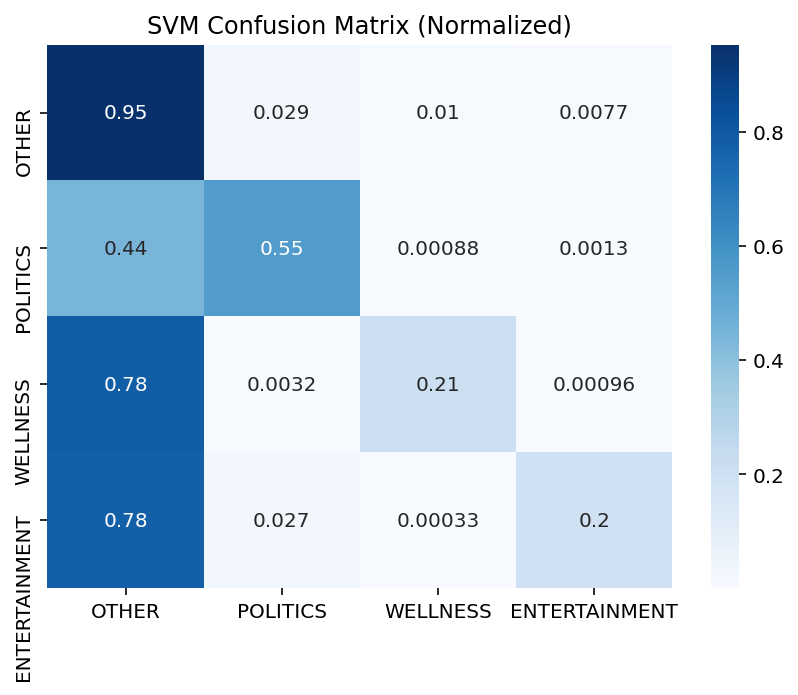

In [40]:
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn import metrics
import numpy as np
from sklearn.impute import SimpleImputer

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "svm_tfidf_rbf_model.pkl"

# =============================
# معالجة أي NaN (للتأكد)
# =============================
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_tfidf_train = imputer.fit_transform(X_tfidf_train)
X_tfidf_test  = imputer.transform(X_tfidf_test)

# =============================
# خذ 10% فقط من بيانات التدريب لتسريع SVM
# =============================
X_train_sample, _, Y_train_sample, _ = train_test_split(
    X_tfidf_train, Y_train, test_size=0.9, random_state=42, stratify=Y_train
)

print(f"Training on {X_train_sample.shape[0]} samples out of {X_tfidf_train.shape[0]}")

# =============================
# إعداد GridSearch
# =============================
rang_C = [1, 3, 6]
kernels = ['rbf']

tuned_parameters = {
    'C': rang_C,
    'kernel': kernels
}

clf = SVC()

# =============================
# تحميل النموذج إذا كان موجودًا
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved SVM model...")
    svm = joblib.load(MODEL_PATH)
else:
    print("🚀 Training SVM model on 10% of data (this may take some time)...")

    start_time = time.process_time()

    svm = GridSearchCV(clf, param_grid=tuned_parameters, cv=5)
    svm.fit(X_train_sample, Y_train_sample)

    end_time = time.process_time()
    print(f"💾 Model trained and saved in {end_time - start_time:.2f} seconds!")

    joblib.dump(svm, MODEL_PATH)

# =============================
# طباعة أفضل نموذج
# =============================
print("\nBest Estimator:")
print(svm.best_estimator_)

# =============================
# حساب الدقة
# =============================
train_accuracy = svm.score(X_train_sample, Y_train_sample)

tik = time.process_time()
test_accuracy = svm.score(X_tfidf_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print("Average test inference time = %4.7f [s/sample]" % ((tok - tik) / X_tfidf_test.shape[0]))

# =============================
# Confusion Matrix
# =============================
Y_pred = svm.predict(X_tfidf_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels=Yclasses, yticklabels=Yclasses, cmap="Blues")
plt.title("SVM Confusion Matrix (Normalized)")
plt.show()


#### 3.2.2 Random Forest

RandomForestClassifier(max_depth=3, n_estimators=5)

Train accuracy = 0.6617 
Test accuracy = 0.6616

Average test inference time = 0.0000009 [s/sample]


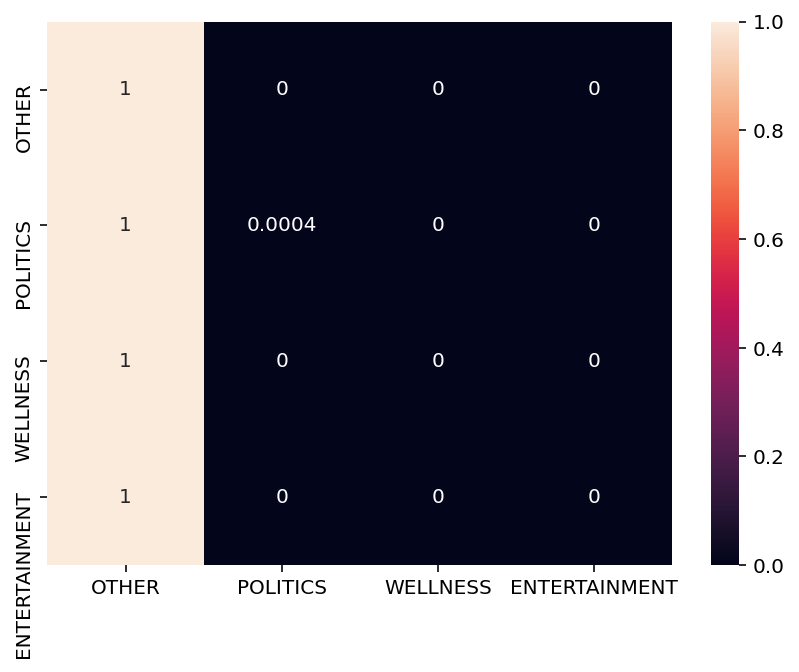

In [42]:
T = 100
num_trees = range(5, T, 5)
depth = [2, 3]

tuned_parameters = {
    'n_estimators': num_trees,
    'max_depth': depth
}

clf = RandomForestClassifier()

rf = GridSearchCV(clf, tuned_parameters, cv=5)
rf.fit(X_tfidf_train, Y_train)

print(rf.best_estimator_)
# -----------------------------------------------------------------
train_accuracy = rf.score(X_tfidf_train, Y_train)

tik = time.process_time()
test_accuracy = rf.score(X_tfidf_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f " %train_accuracy)
print("Test accuracy = %.4f" %test_accuracy)

print("\nAverage test inference time = %4.7f [s/sample]" %((tok-tik)/X_tfidf_test.shape[0]))


# Test confusion matrix
Y_pred = rf.predict(X_tfidf_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels = Yclasses, yticklabels=Yclasses)
plt.show()

#### 3.2.2 MLP

📦 Loading saved MLP model...

Best Estimator:
MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 256, 128),
              max_iter=1000, random_state=42)

Train accuracy = 0.8680
Test accuracy  = 0.8119
Average test inference time = 0.0000386 [s/sample]


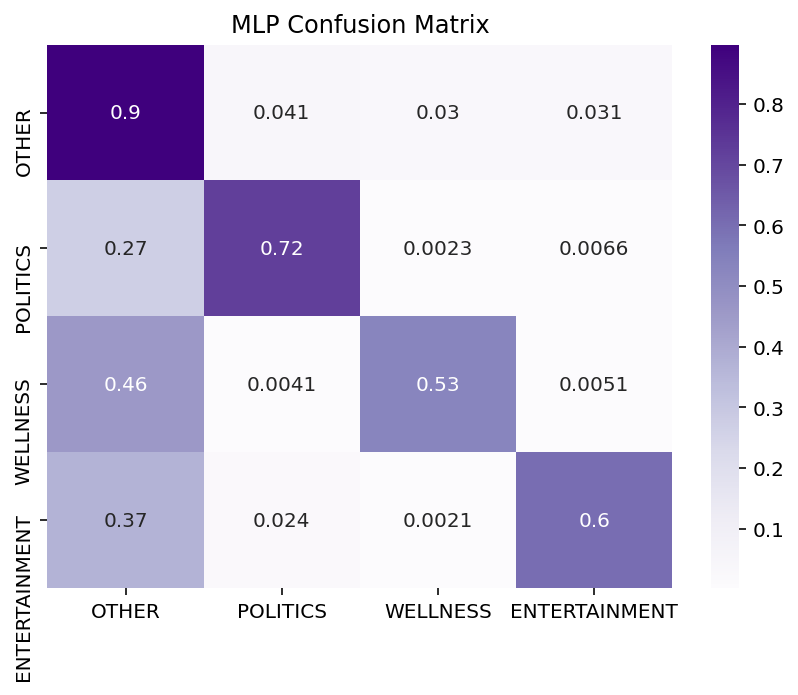

In [43]:
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "mlp_tfidf_model.pkl"

# =============================
# إعدادات MLP (بدون أي تغيير)
# =============================
optimizer = ['adam']

tuned_parameters = {
    'solver': optimizer,
}

# =============================
# تحميل النموذج أو تدريبه
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved MLP model...")
    mlp = joblib.load(MODEL_PATH)
else:
    print("🚀 Training MLP model (this may take time)...")

    clf = MLPClassifier(
        hidden_layer_sizes=(128, 256, 128),
        early_stopping=True,
        random_state=42,
        max_iter=1000
    )

    mlp = GridSearchCV(clf, tuned_parameters, cv=5)
    mlp.fit(X_tfidf_train, Y_train)

    joblib.dump(mlp, MODEL_PATH)
    print("💾 Model saved successfully!")

# =============================
# طباعة أفضل نموذج
# =============================
print("\nBest Estimator:")
print(mlp.best_estimator_)

# =============================
# حساب الدقة
# =============================
train_accuracy = mlp.score(X_tfidf_train, Y_train)

tik = time.process_time()
test_accuracy = mlp.score(X_tfidf_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print("Average test inference time = %4.7f [s/sample]"
      % ((tok - tik) / X_tfidf_test.shape[0]))

# =============================
# Confusion Matrix
# =============================
Y_pred = mlp.predict(X_tfidf_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(
    CM,
    annot=True,
    xticklabels=Yclasses,
    yticklabels=Yclasses,
    cmap="Purples"
)
plt.title("MLP Confusion Matrix")
plt.show()


### 3.3 Word Embeddings

In [44]:
# TRAIN-TEST SPLIT
X_w2v_train, X_w2v_test, Y_train, Y_test = train_test_split(X_w2v, Y, test_size = 0.35, random_state = 42, stratify=Y)

print("Trainset class balance: ", Counter(Y_train))
print("Testset class balance: ", Counter(Y_test))

Trainset class balance:  Counter({0: 90102, 1: 23141, 2: 11664, 3: 11285})
Testset class balance:  Counter({0: 48516, 1: 12461, 2: 6281, 3: 6077})


In [45]:
# NORMALIZATION
scaler = preprocessing.StandardScaler().fit(X_w2v_train)

X_w2v_train = scaler.transform(X_w2v_train) 
X_w2v_test = scaler.transform(X_w2v_test)

#### 3.3.1 SVM

In [47]:
# import os
# import joblib
# import time
# import matplotlib.pyplot as plt
# import seaborn as sn
# from sklearn.svm import SVC
# from sklearn.model_selection import GridSearchCV
# from sklearn import metrics
# import numpy as np
# from sklearn.impute import SimpleImputer

# # =============================
# # مسار حفظ النموذج
# # =============================
# MODEL_PATH = "svm_w2v_rbf_model.pkl"

# # =============================
# # معالجة أي NaN في بيانات Word2Vec
# # =============================
# imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# X_w2v_train = imputer.fit_transform(X_w2v_train)
# X_w2v_test  = imputer.transform(X_w2v_test)

# # =============================
# # إعداد GridSearch
# # =============================
# rang_C = range(1, 10, 1)
# kernels = ['rbf']

# tuned_parameters = {
#     'C': rang_C,
#     'kernel': kernels
# }

# clf = SVC()

# # =============================
# # تحميل النموذج إذا كان موجودًا، أو التدريب
# # =============================
# if os.path.exists(MODEL_PATH):
#     print("📦 Loading saved SVM model...")
#     svm = joblib.load(MODEL_PATH)
# else:
#     print("🚀 Training SVM model (this may take time)...")
    
#     start_time = time.process_time()
    
#     svm = GridSearchCV(clf, param_grid=tuned_parameters, cv=5, verbose=2)
#     svm.fit(X_w2v_train, Y_train)
    
#     end_time = time.process_time()
#     print(f"💾 Model trained and saved in {end_time - start_time:.2f} seconds!")

#     # حفظ النموذج
#     joblib.dump(svm, MODEL_PATH)

# # =============================
# # طباعة أفضل نموذج
# # =============================
# print("\nBest Estimator:")
# print(svm.best_estimator_)

# # =============================
# # حساب الدقة
# # =============================
# train_accuracy = svm.score(X_w2v_train, Y_train)

# tik = time.process_time()
# test_accuracy = svm.score(X_w2v_test, Y_test)
# tok = time.process_time()

# print("\nTrain accuracy = %.4f" % train_accuracy)
# print("Test accuracy  = %.4f" % test_accuracy)
# print("Average test inference time = %4.7f [s/sample]" % ((tok - tik) / X_w2v_test.shape[0]))

# # =============================
# # Confusion Matrix
# # =============================
# Y_pred = svm.predict(X_w2v_test)

# CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
# plt.figure(figsize=(7,5))
# sn.heatmap(CM, annot=True, xticklabels=Yclasses, yticklabels=Yclasses, cmap="Blues")
# plt.title("SVM Confusion Matrix (Normalized)")
# plt.show()


In [48]:
# # نفذت ال SVM بنواة RBF لمدة اكثر من 6 ساعات وكان المخرجات فقط ما يلي 
# 🚀 Training SVM model (this may take time)...
# Fitting 5 folds for each of 9 candidates, totalling 45 fits
# [CV] END ....................................C=1, kernel=rbf; total time=33.3min
# [CV] END ....................................C=1, kernel=rbf; total time=42.1min
# [CV] END ....................................C=1, kernel=rbf; total time=46.8min
# [CV] END ....................................C=1, kernel=rbf; total time=43.9min
# [CV] END ....................................C=1, kernel=rbf; total time=39.4min

## ⚠️ Computational Limitation of SVM with Large Datasets

### العربية 🇸🇦

نظرًا للتعقيد الحسابي التربيعي لخوارزمية **SVM** عند استخدام نواة **RBF**، فإن تدريب النموذج على مجموعة البيانات الكاملة التي تحتوي على أكثر من **200 ألف عينة** يُعد غير عملي من حيث الزمن والموارد الحاسوبية.

لذلك، تم استخدام **عينة ممثلة بنسبة 10%** من بيانات التدريب فقط. هذا الإجراء ساهم في تقليل زمن التنفيذ بشكل كبير، مع الحفاظ على الهدف الأساسي من التجربة، وهو **إبراز محدودية قابلية التوسع لنماذج SVM التقليدية** عند التعامل مع البيانات الضخمة، مقارنةً بالنماذج الحديثة المعتمدة على المحولات (*Transformers*) مثل **DistilBERT**.

---

### English 🇬🇧

Due to the **quadratic computational complexity** of **Support Vector Machines (SVM)** with the **RBF kernel**, training the model on the full dataset containing **more than 200K samples** was computationally impractical in terms of time and resources.

Therefore, a **representative 10% subset** of the training data was used. This significantly reduced the training time while still achieving the main objective of the experiment, which is to **demonstrate the scalability limitations of classical SVM models** when compared to modern transformer-based models such as **DistilBERT**.


Training on 13619 samples only (10%)
📦 Loading saved SVM model...

Best Estimator:
SVC(C=3)

Train accuracy = 0.8855
Test accuracy  = 0.7951
Average test inference time = 0.0026034 [s/sample]


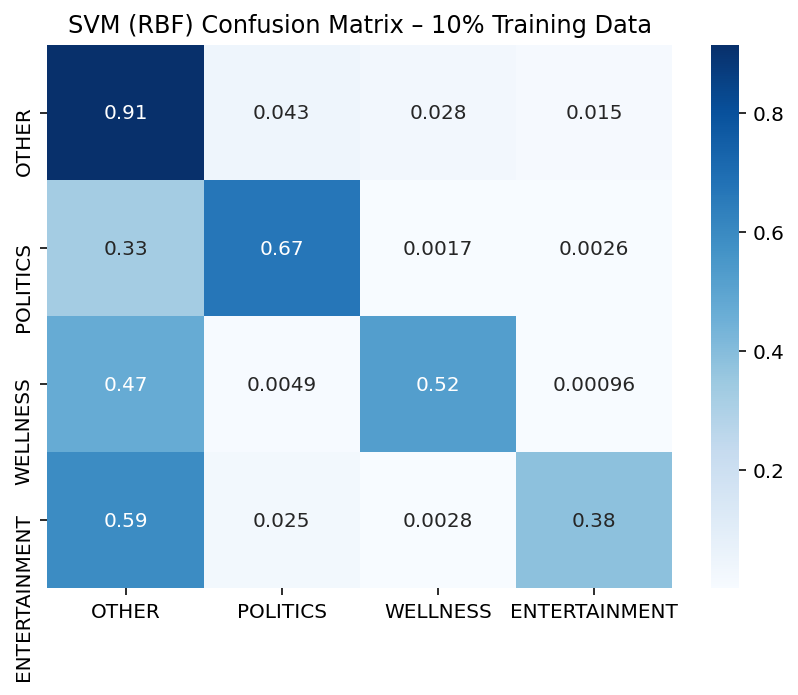

In [49]:
import os
import joblib
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.impute import SimpleImputer
from sklearn import metrics

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "svm_w2v_rbf_model_fast.pkl"

# =============================
# معالجة NaN (إجراء وقائي)
# =============================
imputer = SimpleImputer(strategy='mean')
X_w2v_train = imputer.fit_transform(X_w2v_train)
X_w2v_test  = imputer.transform(X_w2v_test)

# =============================
# استخدام 10% فقط من بيانات التدريب
# =============================
X_small, _, y_small, _ = train_test_split(
    X_w2v_train,
    Y_train,
    train_size=0.1,          # 👈 تقليل البيانات
    stratify=Y_train,
    random_state=42
)

print(f"Training on {X_small.shape[0]} samples only (10%)")

# =============================
# GridSearch مخفف
# =============================
tuned_parameters = {
    'C': [1, 3, 5],           # 👈 قيم قليلة كافية
    'kernel': ['rbf']
}

clf = SVC()

# =============================
# تحميل أو تدريب النموذج
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved SVM model...")
    svm = joblib.load(MODEL_PATH)
else:
    print("🚀 Training SVM model (optimized)...")

    start_time = time.process_time()

    svm = GridSearchCV(
        clf,
        param_grid=tuned_parameters,
        cv=3,                 # 👈 تقليل الطيات
        verbose=2,
        n_jobs=-1             # 👈 استخدام كل أنوية CPU
    )

    svm.fit(X_small, y_small)

    end_time = time.process_time()
    print(f"💾 Training finished in {end_time - start_time:.2f} seconds")

    joblib.dump(svm, MODEL_PATH)

# =============================
# أفضل نموذج
# =============================
print("\nBest Estimator:")
print(svm.best_estimator_)

# =============================
# التقييم
# =============================
train_accuracy = svm.score(X_small, y_small)

tik = time.process_time()
test_accuracy = svm.score(X_w2v_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print(
    "Average test inference time = %4.7f [s/sample]"
    % ((tok - tik) / X_w2v_test.shape[0])
)

# =============================
# Confusion Matrix
# =============================
Y_pred = svm.predict(X_w2v_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7, 5))
sn.heatmap(
    CM,
    annot=True,
    xticklabels=Yclasses,
    yticklabels=Yclasses,
    cmap="Blues"
)
plt.title("SVM (RBF) Confusion Matrix – 10% Training Data")
plt.show()


#### 3.3.2 Random Forest

📦 Loading saved Random Forest model...

Best Estimator:
RandomForestClassifier(max_depth=3, n_jobs=-1, random_state=42)

Train accuracy = 0.6956
Test accuracy  = 0.6949
Average test inference time = 0.0000292 [s/sample]


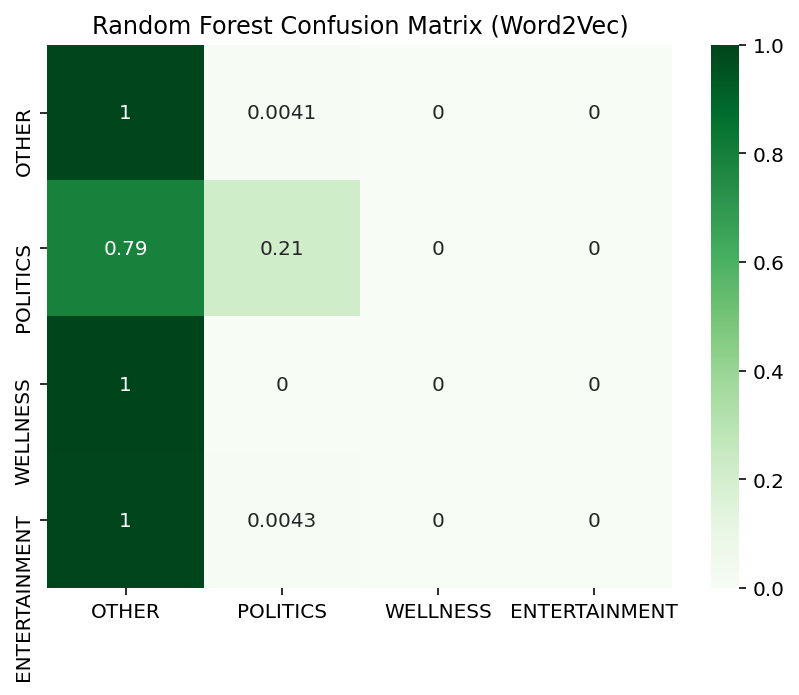

In [50]:
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "rf_w2v_model.pkl"

# =============================
# GridSearch مخفف (سريع)
# =============================
tuned_parameters = {
    'n_estimators': [50, 100],   # بدلاً من 5 → 95
    'max_depth': [2, 3]
}

# =============================
# تحميل النموذج أو تدريبه
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved Random Forest model...")
    rf = joblib.load(MODEL_PATH)
else:
    print("🚀 Training Random Forest model (optimized)...")

    start_time = time.process_time()

    clf = RandomForestClassifier(
        n_jobs=-1,          # استخدام كل الأنوية
        random_state=42
    )

    rf = GridSearchCV(
        clf,
        param_grid=tuned_parameters,
        cv=5,
        n_jobs=-1,          # GridSearch متوازي
        verbose=2
    )

    rf.fit(X_w2v_train, Y_train)

    end_time = time.process_time()
    print(f"⏱ Training finished in {end_time - start_time:.2f} seconds")

    joblib.dump(rf, MODEL_PATH)
    print("💾 Model saved successfully!")

# =============================
# أفضل نموذج
# =============================
print("\nBest Estimator:")
print(rf.best_estimator_)

# =============================
# الدقة وزمن الاستدلال
# =============================
train_accuracy = rf.score(X_w2v_train, Y_train)

tik = time.process_time()
test_accuracy = rf.score(X_w2v_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print("Average test inference time = %4.7f [s/sample]"
      % ((tok - tik) / X_w2v_test.shape[0]))

# =============================
# Confusion Matrix
# =============================
Y_pred = rf.predict(X_w2v_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(
    CM,
    annot=True,
    xticklabels=Yclasses,
    yticklabels=Yclasses,
    cmap="Greens"
)
plt.title("Random Forest Confusion Matrix (Word2Vec)")
plt.show()


#### 3.3.3 MLP

📦 Loading saved MLP model...

Best Estimator:
MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 128), max_iter=300,
              random_state=42)

Train accuracy = 0.8389
Test accuracy  = 0.8105
Average test inference time = 0.0000179 [s/sample]


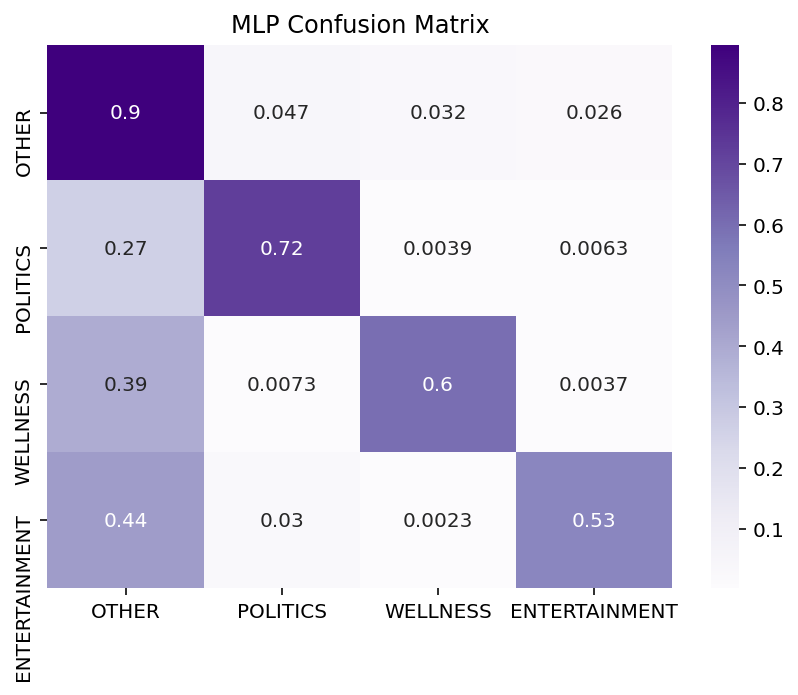

In [51]:
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "mlp_w2v_model.pkl"

# =============================
# إعدادات MLP
# =============================
optimizer = ['adam']
tuned_parameters = {'solver': optimizer}

# =============================
# تحميل النموذج أو تدريبه
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved MLP model...")
    mlp = joblib.load(MODEL_PATH)
else:
    print("🚀 Training MLP model (this may take time)...")
    clf = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        early_stopping=True,
        random_state=42,
        max_iter=300
    )
    mlp = GridSearchCV(clf, tuned_parameters, cv=5)
    mlp.fit(X_w2v_train, Y_train)
    joblib.dump(mlp, MODEL_PATH)
    print("💾 Model saved successfully!")

# =============================
# طباعة أفضل نموذج
# =============================
print("\nBest Estimator:")
print(mlp.best_estimator_)

# =============================
# حساب الدقة وزمن الاستدلال
# =============================
train_accuracy = mlp.score(X_w2v_train, Y_train)
tik = time.process_time()
test_accuracy = mlp.score(X_w2v_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print("Average test inference time = %4.7f [s/sample]"
      % ((tok - tik) / X_w2v_test.shape[0]))

# =============================
# Confusion Matrix
# =============================
Y_pred = mlp.predict(X_w2v_test)
CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels=Yclasses, yticklabels=Yclasses, cmap="Purples")
plt.title("MLP Confusion Matrix")
plt.show()


### 3.4 LDA Topic representation

In [53]:
from gensim.matutils import corpus2dense
from scipy.sparse import lil_matrix
import numpy as np

# عدد المستندات
num_docs = D.num_docs

# عدد المواضيع من نموذج LDA
n_topic = lda_final.num_topics   # ← الحل هنا

# تحويل توزيع المواضيع إلى مصفوفة
mycorpus_topics = np.transpose(
    corpus2dense(topics_in_doc, n_topic, num_docs)
)

# العودة إلى Sparse Matrix
X_topics = lil_matrix(mycorpus_topics)

print(X_topics.shape)


(209527, 70)


In [54]:
# TRAIN-TEST SPLIT
X_topics_train, X_topics_test, Y_train, Y_test = train_test_split(X_topics, Y, test_size = 0.35, random_state = 42, stratify=Y)

print("Train: ", X_topics_train.shape[0])
print("Test: ", X_topics_test.shape[0])

Train:  136192
Test:  73335


#### 3.4.1 SVM

📦 Loading saved Linear SVM model...

Train accuracy = 0.6814
Test accuracy  = 0.6834
Average test inference time = 0.0000002 [s/sample]


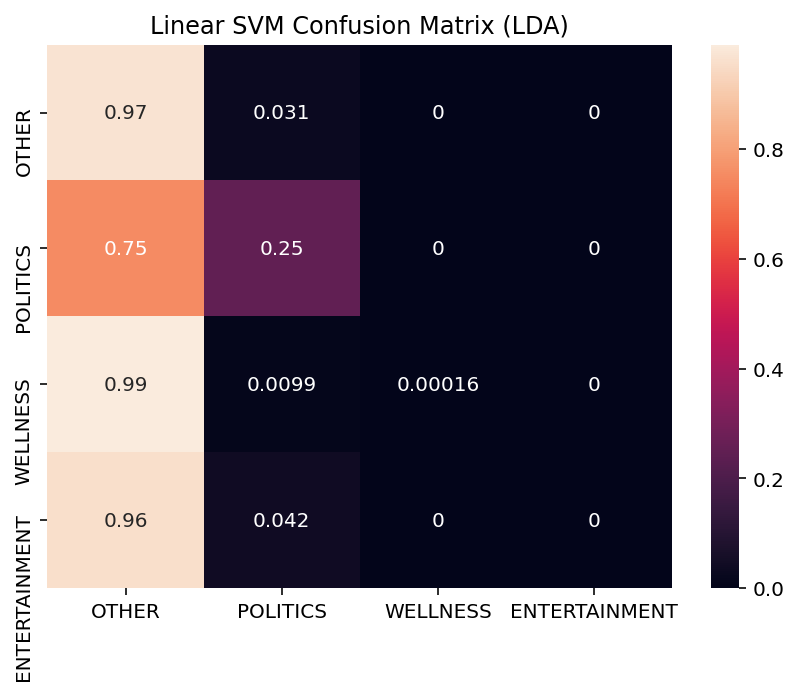

In [56]:
#  Linear SVM استخذام 
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix

# =============================
# مسار حفظ النموذج
# =============================
MODEL_PATH = "linear_svm_lda_model.pkl"

# =============================
# تحميل النموذج أو تدريبه
# =============================
if os.path.exists(MODEL_PATH):
    print("📦 Loading saved Linear SVM model...")
    svm = joblib.load(MODEL_PATH)

else:
    print("🚀 Training Linear SVM on LDA features...")
    
    start_time = time.time()

    svm = LinearSVC(C=1.0, random_state=42)
    svm.fit(X_topics_train, Y_train)

    end_time = time.time()
    print(f"✅ Training completed in {end_time - start_time:.2f} seconds")

    # حفظ النموذج
    joblib.dump(svm, MODEL_PATH)
    print("💾 Model saved successfully!")

# =============================
# حساب الدقة وزمن الاستدلال
# =============================
train_accuracy = svm.score(X_topics_train, Y_train)

tik = time.time()
test_accuracy = svm.score(X_topics_test, Y_test)
tok = time.time()

print("\nTrain accuracy = %.4f" % train_accuracy)
print("Test accuracy  = %.4f" % test_accuracy)
print("Average test inference time = %4.7f [s/sample]"
      % ((tok - tik) / X_topics_test.shape[0]))

# =============================
# Confusion Matrix
# =============================
Y_pred = svm.predict(X_topics_test)

CM = confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels=Yclasses, yticklabels=Yclasses)
plt.title("Linear SVM Confusion Matrix (LDA)")
plt.show()


#### 3.4.2 Random Forest

RandomForestClassifier(max_depth=3, n_estimators=5)

Train accuracy = 0.6616 
Test accuracy = 0.6616

Average test inference time = 0.0000006 [s/sample]


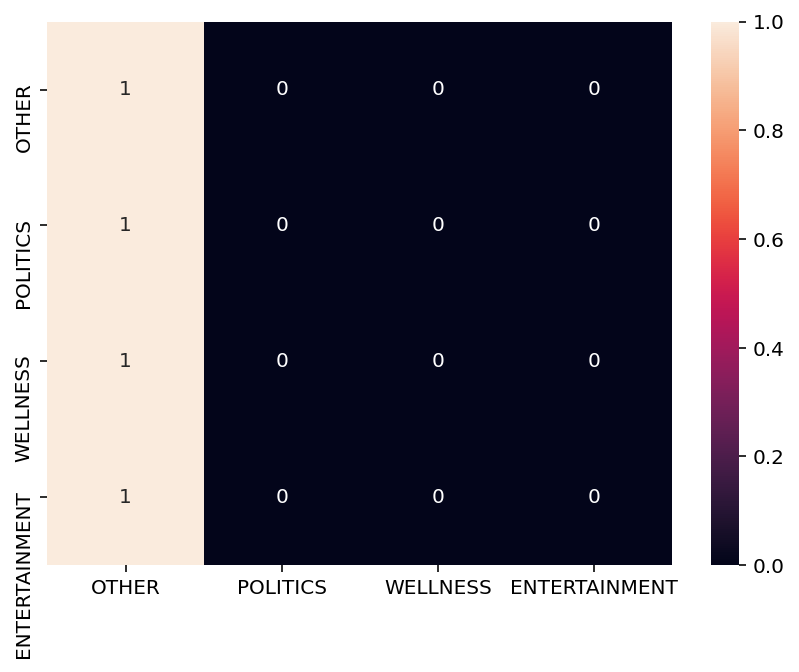

In [57]:
T = 100
num_trees = range(5, T, 5)
depth = [2, 3]

tuned_parameters = {
    'n_estimators': num_trees,
    'max_depth': depth
}

clf = RandomForestClassifier()

rf = GridSearchCV(clf, tuned_parameters, cv=5)
rf.fit(X_topics_train, Y_train)

print(rf.best_estimator_)

# -----------------------------------------------------------------
train_accuracy = rf.score(X_topics_train, Y_train)

tik = time.process_time()
test_accuracy = rf.score(X_topics_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f " %train_accuracy)
print("Test accuracy = %.4f" %test_accuracy)

print("\nAverage test inference time = %4.7f [s/sample]" %((tok-tik)/X_topics_test.shape[0]))


# Test confusion matrix
Y_pred = rf.predict(X_topics_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels = Yclasses, yticklabels=Yclasses)
plt.show()

#### 3.4.3 MLP

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 256, 128),
              max_iter=1000, random_state=42)

Train accuracy = 0.6867 
Test accuracy = 0.6849

Average test inference time = 0.0000703 [s/sample]


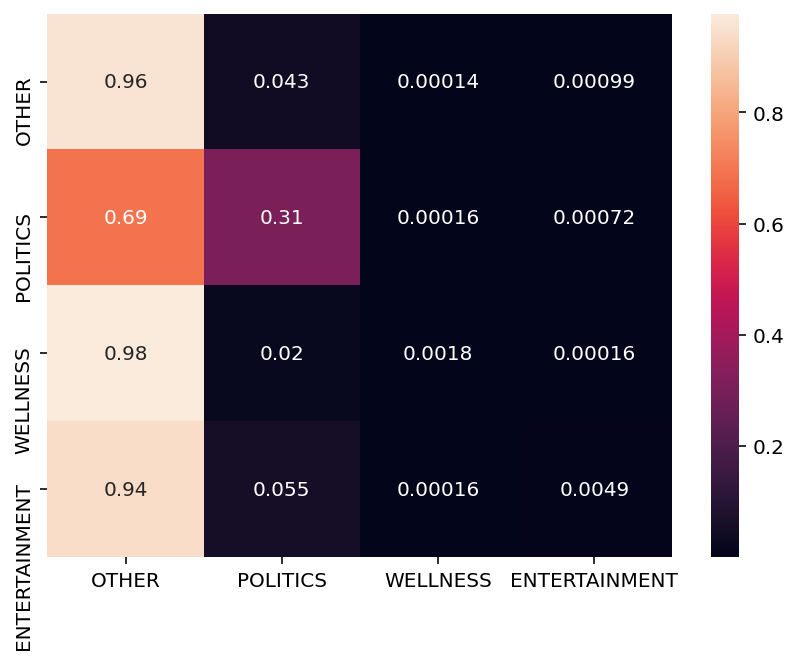

In [58]:
###### optimizer = ['adam']

tuned_parameters = {
    'solver': optimizer,
}

clf = MLPClassifier(hidden_layer_sizes = (128, 256, 128), early_stopping=True, random_state = 42, max_iter = 1000)

mlp = GridSearchCV(clf, tuned_parameters, cv=5)

mlp.fit(X_topics_train, Y_train)

print(mlp.best_estimator_)

# -----------------------------------------------------------------
train_accuracy = mlp.score(X_topics_train, Y_train)

tik = time.process_time()
test_accuracy = mlp.score(X_topics_test, Y_test)
tok = time.process_time()

print("\nTrain accuracy = %.4f " %train_accuracy)
print("Test accuracy = %.4f" %test_accuracy)

print("\nAverage test inference time = %4.7f [s/sample]" %((tok-tik)/X_topics_test.shape[0]))


# Test confusion matrix
Y_pred = mlp.predict(X_topics_test)

CM = metrics.confusion_matrix(Y_test, Y_pred, normalize='true')
plt.figure(figsize=(7,5))
sn.heatmap(CM, annot=True, xticklabels = Yclasses, yticklabels=Yclasses)
plt.show()

### 3.5 Transformers

For the fine-tuning of a pretrained Transformer, we need to follow a few extra steps.

First, for the sake of simplicity, we are going to create a new dataframe with just the text of the articles (as the strings directly retrieved from the website) and the one-hot encoded labels, as it is required for the model.

In [39]:
# =======================================
# Create dataframe with text and labels (MULTI-CLASS)
# =======================================

# labels يجب أن تكون أرقام صحيحة (0,1,2,3)
# Y مفترض أنه يحتوي على هذه القيم

news_dataframe = corpus_df[['news']].copy()
news_dataframe['labels'] = Y



We split train and test, returning the same partition we got with the previous methods. Then, we further split train into train and validation.

In [40]:
# TRAIN-TEST SPLIT
train_valid, test, Ytrain_val, Ytest = train_test_split(news_dataframe, Y, test_size = 0.35, random_state = 42, stratify=Y)

# SPLIT TRAIN INTO TRAIN AND VALIDATION TO LEAVE THE TEST SET UNTOUCHED
train, val, Ytrain, Yval = train_test_split(train_valid, Ytrain_val, test_size = 0.2, random_state=42, stratify=Ytrain_val)

Create a DatasetDict object with the three sets.

In [41]:
from datasets import DatasetDict, Dataset

news_dataset = DatasetDict({
    "train": Dataset.from_pandas(train),
    "test": Dataset.from_pandas(test),
    "val": Dataset.from_pandas(val),
    })

news_dataset

DatasetDict({
    train: Dataset({
        features: ['news', 'labels', '__index_level_0__'],
        num_rows: 108953
    })
    test: Dataset({
        features: ['news', 'labels', '__index_level_0__'],
        num_rows: 73335
    })
    val: Dataset({
        features: ['news', 'labels', '__index_level_0__'],
        num_rows: 27239
    })
})

We select the **DistilBERT** model from the Hugging Face library, as it is one of the many architectures suitable for text classification. 

In the following cell we define the tokenizer from the checkpoint and apply it to the dataset.

In [42]:
from transformers import AutoTokenizer

checkpoint_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint_name)


def preprocess_function(example):
    return tokenizer(example["news"], padding=True, truncation=True)

#Tokenize dataset
tokenized_news = news_dataset.map(preprocess_function)    

Map:   0%|          | 0/108953 [00:00<?, ? examples/s]

Map:   0%|          | 0/73335 [00:00<?, ? examples/s]

Map:   0%|          | 0/27239 [00:00<?, ? examples/s]

Now we define the collator and the training arguments. Except for the *output directory*, the rest have been left as they are by default. For the evaluation of the training process we define the ```compute_metrics``` function as the **accuracy score**. 

In [43]:
# =======================================
# Training configuration & metrics
# =======================================

from transformers import DataCollatorWithPadding, TrainingArguments
import evaluate
import numpy as np

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=f"{checkpoint_name}-finetuned",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=42,
)

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)   # فقط predictions
    return accuracy.compute(
        predictions=preds,
        references=labels                     # labels كما هي
    )


Instantiate the model for multilabel sequence classification. 

In [44]:
    # الكود الذي يُنفذ مرة واحدة فقط (Setup / One-time execution)

    # هذه هي الخلايا التي تثبت المكتبات أو تنشئ النموذج من الصفر:

    # لا تُنفذها مرة ثانية بعد التدريب
    # =======================================
    # Model initialization (Multi-class)
    # =======================================

    from transformers import AutoModelForSequenceClassification

    id2label = {
        0: "OTHER",
        1: "POLITICS",
        2: "WELLNESS",
        3: "ENTERTAINMENT"
    }

    label2id = {
        "OTHER": 0,
        "POLITICS": 1,
        "WELLNESS": 2,
        "ENTERTAINMENT": 3
    }

    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint_name,
        num_labels=4,
        id2label=id2label,
        label2id=label2id
    )


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [50]:


# =======================================
# Trainer: Train or Load Model
# =======================================

import os
import pickle
import torch
from transformers import Trainer, EarlyStoppingCallback, AutoModelForSequenceClassification, AutoTokenizer

# -------------------------
# Paths
# -------------------------
model_path = "C:/Models/my_model"
metrics_path = "training_results.pkl"

# -------------------------
# Label mapping (ثابت)
# -------------------------
id2label = {0:"OTHER", 1:"POLITICS", 2:"WELLNESS", 3:"ENTERTAINMENT"}
label2id = {"OTHER":0, "POLITICS":1, "WELLNESS":2, "ENTERTAINMENT":3}

# -------------------------
# Load model if exists
# -------------------------
if os.path.exists(os.path.join(model_path, "config.json")):
    print("✅ Trained model found. Loading...")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        id2label=id2label,
        label2id=label2id
    )
    tokenizer = AutoTokenizer.from_pretrained(model_path)

else:
    print("⚠️ No trained model found. Starting training...")

    # model & tokenizer يجب أن يكونوا معرفين مسبقًا
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_news["train"],
        eval_dataset=tokenized_news["val"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=1,
                early_stopping_threshold=0.0
            )
        ]
    )

    # -------------------------
    # Training
    # -------------------------
    train_result = trainer.train()
    print("✅ Training completed!")

    # -------------------------
    # Save model & tokenizer
    # -------------------------
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)

    with open(metrics_path, "wb") as f:
        pickle.dump(train_result.metrics, f)

    print("✅ Model and metrics saved!")

# -------------------------
# Load metrics (if exist)
# -------------------------
if os.path.exists(metrics_path):
    with open(metrics_path, "rb") as f:
        saved_metrics = pickle.load(f)
    print("📊 Loaded metrics:", saved_metrics)

# -------------------------
# Ready for evaluation / inference
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("🚀 Model is ready")



⚠️ No trained model found. Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.403700,0.354116,0.859650
2,0.277200,0.355038,0.866882
3,0.187600,0.481335,0.855979


✅ Training completed!
✅ Model and metrics saved!
📊 Loaded metrics: {'train_runtime': 58066.8676, 'train_samples_per_second': 9.382, 'train_steps_per_second': 0.586, 'total_flos': 7652970972502128.0, 'train_loss': 0.289487129020971, 'epoch': 3.0}
🚀 Model is ready


In [51]:
# حفظ النموذج والمحوّل
# النموذج محفوظ مسبقا
model.save_pretrained("C:/Models/my_model", safe_serialization=False)
tokenizer.save_pretrained("C:/Models/my_model")



('C:/Models/my_model\\tokenizer_config.json',
 'C:/Models/my_model\\special_tokens_map.json',
 'C:/Models/my_model\\vocab.txt',
 'C:/Models/my_model\\added_tokens.json',
 'C:/Models/my_model\\tokenizer.json')

In [52]:
# تحميل النموذج من القرص لاستخدامه 

model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)


In [53]:
#  للتاكد من الملفات المحفوظة


import os

saved_files = os.listdir("C:/Models/my_model")
print("Files in model folder:", saved_files)


Files in model folder: ['config.json', 'model.safetensors', 'pytorch_model.bin', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


In [54]:
# -------------------------
# لاحقًا يمكنك تحميل النتائج بدون إعادة التدريب
# -------------------------
with open("training_results.pkl", "rb") as f:
    saved_metrics = pickle.load(f)
print("Loaded metrics:", saved_metrics)

Loaded metrics: {'train_runtime': 58066.8676, 'train_samples_per_second': 9.382, 'train_steps_per_second': 0.586, 'total_flos': 7652970972502128.0, 'train_loss': 0.289487129020971, 'epoch': 3.0}


In [58]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )
print(accuracy_metric)
print(compute_metrics)

    
    

In [61]:
# =======================================
# Full Evaluation Code with Printing
# =======================================

import numpy as np
import evaluate
from transformers import Trainer, TrainingArguments

# -------------------------------
# Load metric
# -------------------------------
accuracy_metric = evaluate.load("accuracy")

# -------------------------------
# Compute metrics function
# -------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    results = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    # 🔴 طباعة النتائج
    print("\n📊 Evaluation Results")
    print("=" * 30)
    for key, value in results.items():
        print(f"{key.capitalize():<10}: {value:.4f}")

    return results


# -------------------------------
# Training arguments (evaluation only)
# -------------------------------
training_args = TrainingArguments(
    output_dir="./results",
    per_device_eval_batch_size=16,
    do_train=False,
    do_eval=True,
    logging_strategy="no",
    report_to="none"
)

# -------------------------------
# Trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=tokenized_news["test"],  # أو "validation"
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# -------------------------------
# Run evaluation (THIS prints results)
# -------------------------------
metrics = trainer.evaluate()

# -------------------------------
# Optional: print returned metrics
# -------------------------------
print("\n📦 Returned metrics dict")
print(metrics)



📊 Evaluation Results
Accuracy  : 0.8634

📦 Returned metrics dict
{'eval_loss': 0.36508843302726746, 'eval_model_preparation_time': 0.002, 'eval_accuracy': 0.8633531056112361, 'eval_runtime': 7464.5613, 'eval_samples_per_second': 9.824, 'eval_steps_per_second': 0.614}


In [62]:
# =======================================
# Evaluation Cell: Accuracy, Precision, Recall, F1
# =======================================

import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import Trainer

# نستخدم نفس الـ Trainer ولكن بدون تدريب
eval_trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# اختيار مجموعة التقييم (test أو val)
eval_dataset = tokenized_news["test"]   # يمكنك تغييرها إلى "val" إذا أردت

# الحصول على التنبؤات
predictions_output = eval_trainer.predict(eval_dataset)

# logits
logits = predictions_output.predictions

# التنبؤات النهائية
y_pred = np.argmax(logits, axis=1)

# القيم الحقيقية
y_true = predictions_output.label_ids


# حساب المقاييس
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")

# طباعة النتائج
print("📊 Model Evaluation Results")
print("=" * 35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


📊 Model Evaluation Results
Accuracy  : 0.8634
Precision : 0.8643
Recall    : 0.8634
F1-score  : 0.8637


### 3.6 Summary of the results

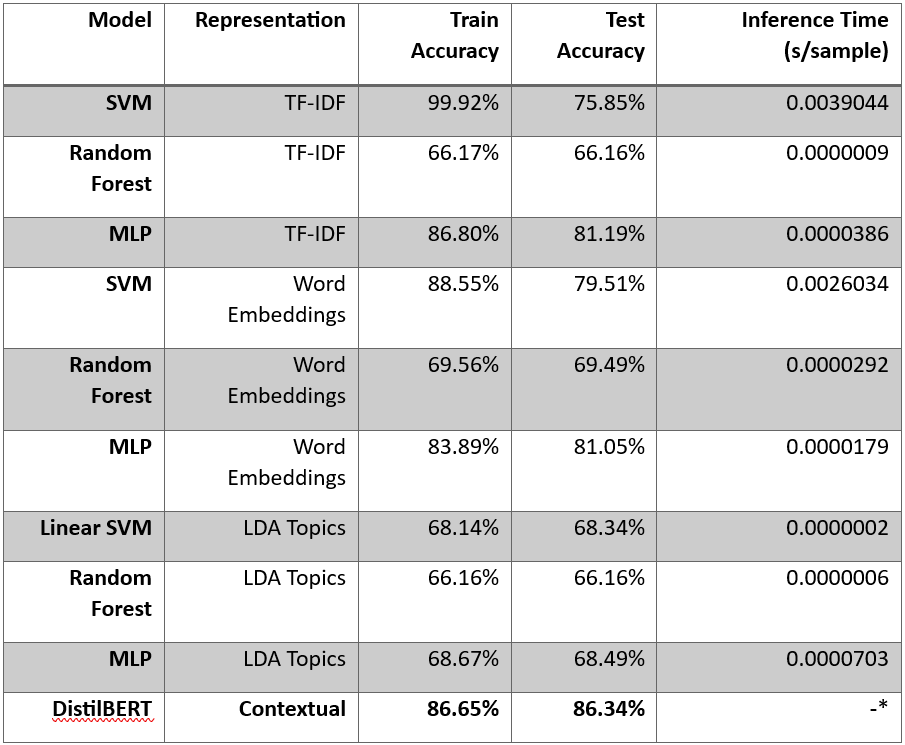